In [1]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) return false;

<IPython.core.display.Javascript object>

In [2]:
import dataset, plots, features

# Wstęp

Projekt jest realizowany w ramach przedmiotu Projekt Indywidualny na Politechnice Warszawskiej, na kierunku Informatyka Stosowana. Jego celem jest analiza oraz optymalizacja portfela spółek giełdowych z wykorzystaniem metod ilościowych, takich jak symulacja Monte Carlo, analiza techniczna, analiza fundamentalna oraz wybrane metody uczenia maszynowego.

## Benchmark

Wyniki analizowanych strategii będą porównywane z indeksem [**S&P 500** (Standard & Poor's 500)](https://pl.wikipedia.org/wiki/S%26P_500), który jest jednym z najczęściej stosowanych benchmarków dla rynku akcji w Stanach Zjednoczonych. Indeks ten reprezentuje szeroki przekrój dużych i płynnych spółek, a jego wyniki są często traktowane jako przybliżenie zachowania całego rynku akcji (reprezentuje około 80% kapitalizacji). Ze względu na charakter globalny dużej większości składowych indeksu, indeks ten nie tylko powinien dobrze odzwierciedlać gospodarkę Stanów Zjednoczonych, ale również i gospodarkę globalną.

![S&P 500 50-Year Chart](images/1-sp500-50yo-chart.png)
Źródło: [Stooq - SPX](https://stooq.com/q/?s=%5Espx&c=50y&t=c&a=lg&b=0)

Indeks jest również odpowiednio zdywersyfikowany – spółki należą do różnych sektorów, jednak dominujący jest sektor technologiczny, co wynika z faktu, że S&P 500 jest indeksowany kapitalizacją rynkową, a największe spółki technologiczne mają największe wagi, co znacząco wpływa na wycenę całego indeksu.

<!-- ![S&P 500 Sector Components (January 2025)](images/2-sp500-sector-components.svg)
Źródło: [Forex – Trading the S&P 500](https://www.forex.com/en-au/index-trading/trading-the-sp-500/) -->

<img src="images/2-sp500-sector-components.svg"
     alt="S&P 500 Sector Components (January 2025)"
     style="background-color: white; padding: 10px; border-radius: 8px;" />
Źródło: [Forex – Trading the S&P 500](https://www.forex.com/en-au/index-trading/trading-the-sp-500/)

Największe 7 spółek w indeksie S&P 500 są określane jako Wspaniała Siódemka (The Magnificent Seven).

![S&P 500 Mag 7](images/3-sp500-mag-7.png)
Źródło: [Seeking Alpha - 2026 Market Outlook](https://seekingalpha.com/article/4856133-2026-market-outlook-the-s-and-p-500-illusion-and-the-small-cap-pivot)

Istnieje również wersja indeksu S&P 500 z równoważeniem wag spółek (**S&P 500 equal-weighted**), w której każda spółka ma taki sam udział w indeksie, niezależnie od kapitalizacji rynkowej. W tej wersji dominacja największych spółek technologicznych jest znacznie mniejsza, a wpływ mniejszych spółek na wartość indeksu staje się bardziej widoczny.

Porównanie z S&P 500 pozwala ocenić, czy zastosowane metody selekcji spółek oraz konstrukcji portfela prowadzą do rezultatów lepszych lub porównywalnych z prostą strategią inwestowania w szeroki indeks rynkowy. Jest to istotne, ponieważ wiele aktywnych strategii inwestycyjnych w długim okresie nie jest w stanie konsekwentnie osiągać wyników lepszych od indeksów rynkowych. Oczywiście wszystkie stopy zwrotu, zarówno indeksu, jak i portfeli, są wyrażone w wartościach nominalnych i obciążone wpływem inflacji, co oznacza, że realne stopy zwrotu są niższe. Jednak przy porównaniu z benchmarkiem względny wynik pozostaje niezmieniony, dlatego wpływ inflacji nie zmienia wniosków dotyczących efektywności strategii.  
Wpływ podatków także nie jest uwzględniany, co pozwala skupić się wyłącznie na porównaniu względnej wydajności portfela względem indeksu.

![Average S&P 500 Returns Per Year](images/4-sp500-returns.png)
Źródło: [TradeThatSwing - Historical Average Stock Market Returns](https://tradethatswing.com/average-historical-stock-market-returns-for-sp-500-5-year-up-to-150-year-averages/)

## Inwestorzy VS Indeks

W teorii, odpowiednio dobrany portfel uzyskać lepsze wyniki niż sam indeks S&P 500 poprzez selekcję spółek o lepszych perspektywach oraz optymalną alokację wag. W praktyce jest to trudne, na co wskazują dane raportu [**SPIVA® U.S. Year-End 2025**](https://www.spglobal.com/spdji/en/spiva/article/spiva-us/) - w 2025 roku 79% wszystkich aktywnych funduszy akcyjnych o dużej kapitalizacji w Stanach Zjednoczonych osiągnęło wyniki gorsze od indeksu S&P 500.

![Funds VS S&P 500](images/5-funds-vs-sp500.png)

Od 2001 do 2025 tylko w latach 2005, 2007 i 2009 udało się pobić S&P 500 większości z nich.

Inwestorzy indywidualni również często nie osiągają wyników lepszych od indeksu. Według raportu [**DALBAR – Quantitative Analysis of Investor Behavior (QAIB) 2024**](https://www.dalbar.com/press-release/investors-missed-the-best-of-2024s-market-gains-latest-dalbar-investor-behavior-report-finds/), przeciętny inwestor giełdowy uzyskał stopę zwrotu na poziomie 16,54%, podczas gdy indeks S&P 500 osiągnął 25,02%. Różnica 848 punktów bazowych była drugą największą w ciągu ostatniej dekady, co pokazuje, że większość inwestorów detalicznych systematycznie nie dorównuje wynikowi szerokiego rynku.

Badania akademickie, takie jak [**Trading Is Hazardous to Your Wealth (Berkeley)**](https://faculty.haas.berkeley.edu/odean/papers%20current%20versions/individual_investor_performance_final.pdf), wskazują, że realne decyzje inwestorów indywidualnych – częste kupno i sprzedaż akcji, próby „timingu” rynku oraz reakcje emocjonalne – znacząco obniżają ich wyniki w porównaniu z prostą strategią buy-and-hold indeksu S&P 500. W przypadku inwestorów indywidualnych często dochodzi do mylenia roli **inwestora** z rolą **spekulanta**, jak wskazuje Benjamin Graham w klasycznej literaturze inwestycyjnej: wielu uczestników rynku podejmuje decyzje krótkoterminowe, oczekując szybkich zysków, zamiast koncentrować się na analizie fundamentalnej i długoterminowej wartości spółki.

## Cel projektu

Celem projektu nie jest bezwzględne pobicie indeksu, lecz racjonalna selekcja i optymalizacja portfela spółek w oparciu o dane historyczne, wskaźniki techniczne i fundamentalne oraz symulacje ryzyka, tak aby uzyskać efektywność porównywalną z benchmarkiem przy kontrolowanym ryzyku.  
Projekt ma również charakter badawczo-eksperymentalny – przetestowanie i porównanie różnych strategii inwestycyjnych, zarówno opartych na danych technicznych, jak i fundamentalnych, a także różnych podejść do selekcji spółek i alokacji wag. Dodatkowo - ocenę ryzyka i stabilności portfela przy użyciu różnych metryk takich jak Sharpe, Sortino czy maksymalne obsunięcie kapitału, a także analizę wyników w warunkach historycznych i przy symulacjach Monte Carlo.

Efekty projektu pozwolą lepiej zrozumieć ograniczenia strategii aktywnych inwestorów i ich realną skuteczność w porównaniu z szerokim indeksem rynkowym.

## Założenia

Projekt opiera się na dwóch głównych założeniach:
1. W teorii, odpowiednio wybrany podzbiór spółek z indeksu S&P 500 powinien wykazywać wyniki lepsze niż sam indeks, dzięki selekcji spółek o wyższych perspektywach.  
2. Próba wykorzystania wszystkich spółek światowych (kolejnym benchmarkiem byłby z pewnością [MSCI World Index](https://www.msci.com/indexes/index/990100)) do budowy strategii portfela byłaby nadmiernie złożona, zarówno pod względem obliczeniowym, jak i dostępności danych.

W związku z tym, analizowane spółki pochodzą wyłącznie z indeksu S&P 500, co pozwala na realistyczne i porównywalne badanie różnych strategii inwestycyjnych przy zachowaniu spójności danych historycznych.

# Dane

Dane są kluczowym elementem projektu. W ramach analiz wykorzystywane są trzy główne typy danych:

- **Skład indeksu S&P 500** – portfele będą tworzone ze spółek wchodzących w skład tego indeksu.
- **Ceny akcji** – niezbędne do symulacji Monte Carlo oraz do narzędzi analizy technicznej.
- **Dane techniczne** – wskaźniki wyliczane na podstawie historycznych cen, używane w strategiach opartych na analizie technicznej.
- **Dane fundamentalne spółek** – obejmujące wybrane wskaźniki finansowe oraz informacje ze sprawozdań finansowych (Rachunek zysków i strat, Bilans oraz Rachunek przepływów pieniężnych), używane w analizie fundamentalnej.

## Wymagania względem danych

1. Wszystkie dane muszą mieć charakter **historyczny**, aby możliwe było poprawne testowanie strategii i modeli w oparciu o warunki rynkowe z przeszłości. Oznacza to, że dane powinny odzwierciedlać stan wiedzy w danym momencie historycznym. Pozwala to uniknąć tzw. **błędu wyprzedzania** informacji (look-ahead bias), który polega na wykorzystaniu w teście danych niedostępnych w momencie podejmowania decyzji, w tym kontekście decyzji inwestycyjnych o składzie portfeli.

2. Dane powinny obejmować odpowiednio **długi okres historyczny**, umożliwiający testowanie strategii inwestycyjnych w dłuższej perspektywie, a nie tylko krótkoterminowych ruchów rynkowych. Inwestowanie to nie spekulacja, wspominając ponownie Grahama.

3. Dane muszą obejmować również spółki, które wypadły z indeksu, lub **spółki, które już nie istnieją**, czyli takie, w których wystąpiła jedna z poniższych sytuacji:
    - bankructwo
    - fuzja lub przejęcie (spółka została wchłonięta przez inną)
    - delisting / wycofanie z giełdy (np. zmiana statusu prywatnego lub restrukturyzacja)
Jest to konieczne, aby uniknąć **błędu przeżywalności** (survivorship bias), czyli sytuacji, w której uwzględnia się wyłącznie spółki przetrwałe. Błąd przeżywalności i błąd wyprzedzania w praktyce mają podobny efekt – w backtestingu modele lub strategie dysponują informacjami o przyszłości, które w rzeczywistości nie były dostępne w danym momencie. Skutkuje to zawyżeniem stóp zwrotu i efektywności strategii, prowadząc do mylnych wniosków o ich skuteczności.

    Poniższa mapa cieplna przedstawia komponenty indeksu S&P 500 z ich 10-letnimi stopami zwrotu. Średnia ważona stopa zwrotu tych spółek jest znacznie wyższa niż 10-letnia stopa zwrotu samego indeksu, którego skład zmieniał się w tym czasie. Ten przykład doskonale ilustruje, jak błąd przeżywalności może nierealistycznie zawyżyć wyniki.

    ![S&P 500 ETF Components' 10-year returns (2026.03.24)](images/6-sp500-etf-components-10y-returns.png)
Źródło: [MarketScreener - S&P 500 ETF Components](https://www.marketscreener.com/quote/index/S-P-500-4985/heatmap/)

4. Dane muszą być **skorygowane o splity akcji** (podział akcji zwiększający ich liczbę w obrocie) oraz o **dywidendy** (część zysku przedsiębiorstwa wypłacana akcjonariuszom).

5. Dane cenowe powinny mieć **spójną częstotliwość** (np. dzienne EOD, tygodniowe, miesięczne), aby umożliwić porównywalne analizy.

6. Dane powinny być **wysokiej jakości** - wolne od błędów, braków oraz duplikatów.

## Dane o składzie indeksu

Do pozyskania danych o składzie indeksu S&P 500 przydatny jest projekt projekt [fja05680/sp500](https://github.com/fja05680/sp500/tree/1bfcb10f2743108de671021ea78217ab07bab2ad) na GitHub. Zawiera on zarówno aktualną, jak i historyczną listę spółek wchodzących w skład indeksu oraz przykładowe notebooki umożliwiające pobranie tych danych. Projekt jest regularnie aktualizowany, co zapewnia dostęp do aktualnych informacji o składzie indeksu. Jednakże, jak sam autor podkreśla, nie ma gwarancji, iż wszystkie dane są w 100% prawidłowe.

### Dane o aktualnym składzie indeksu

Aktualny skład indeksu jest pozyskiwany z [Wikipedii](https://en.wikipedia.org/wiki/List_of_S%26P_500_companies).

In [3]:
dataset.SP500.generate_current(cleanup_old=True)

No generation needed: sp500_2026-04-03.csv already exists.


WindowsPath('D:/Michal/Documents/Education/University/Semestr 4/Projekt indywidualny/Repo/data/external/sp500/sp500_2026-04-03.csv')

In [4]:
plots.summarize_df(dataset.SP500.load_current())

DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Symbol                 503 non-null    str  
 1   Security               503 non-null    str  
 2   GICS Sector            503 non-null    str  
 3   GICS Sub-Industry      503 non-null    str  
 4   Headquarters Location  503 non-null    str  
 5   Date added             503 non-null    str  
 6   CIK                    503 non-null    int64
 7   Founded                503 non-null    str  
dtypes: int64(1), str(7)
memory usage: 31.6 KB
None


,CIK
count,5.030000e+02
mean,8.527212e+05
std,5.787557e+05
min,1.800000e+03
25%,1.062875e+05
50%,9.125950e+05
75%,1.284742e+06
max,2.058873e+06


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927
502,ZTS,Zoetis,Health Care,Pharmaceuticals,"Parsippany, New Jersey",2013-06-21,1555280,1952


### Dane o historycznym składzie indeksu

Historyczny skład indeksu jest budowany na podstawie pliku S&P 500 Historical Components & Changes, udostępnionego wraz z książką [Trading Evolved](https://books.google.pl/books/about/Trading_Evolved.html?id=xSc0yQEACAAJ&source=kp_book_description&redir_esc=y) autorstwa Andreas Clenow, który obejmuje okres 1996–2019. Następnie dane są ręcznie aktualizowane o zmiany po 2019 roku na podstawie informacji z Wikipedia oraz dodatkowych źródeł internetowych, ponieważ sekcja „Selected Changes” nie zawiera pełnej historii modyfikacji indeksu. Końcowy zbiór danych powstaje poprzez scalenie oryginalnego pliku z późniejszymi zmianami oraz wykonanie podstawowego czyszczenia danych, co pozwala uzyskać aktualny plik obejmujący pełną historię zmian składu indeksu.

In [5]:
dataset.SP500.generate_historical(cleanup_old=True)

No generation needed: sp500_historical_2026-04-03.csv already exists.


WindowsPath('D:/Michal/Documents/Education/University/Semestr 4/Projekt indywidualny/Repo/data/external/sp500/sp500_historical_2026-04-03.csv')

In [6]:
sp500_components = dataset.SP500.load_historical()
plots.summarize_df(sp500_components)

DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 2705 entries, 0 to 2704
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   date     2705 non-null   str  
 1   tickers  2705 non-null   str  
dtypes: str(2)
memory usage: 42.4 KB
None


,date,tickers
count,2705,2705
unique,2705,679
top,1996-01-02,"A,AABA,AAPL,ABC,ABI,ABKFQ,ABS,ABT,ACV,ADBE,ADC..."
freq,1,23


,date,tickers
0,1996-01-02,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
1,1996-01-03,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
2703,2025-12-22,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."
2704,2026-01-14,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."


Na podstawie poniższego wykresu przedstawiającego liczbę spółek wchodzących do indeksu na początku każdego roku widać, że mimo nazwy „S&P 500” liczba komponentów nie zawsze wynosi dokładnie 500.

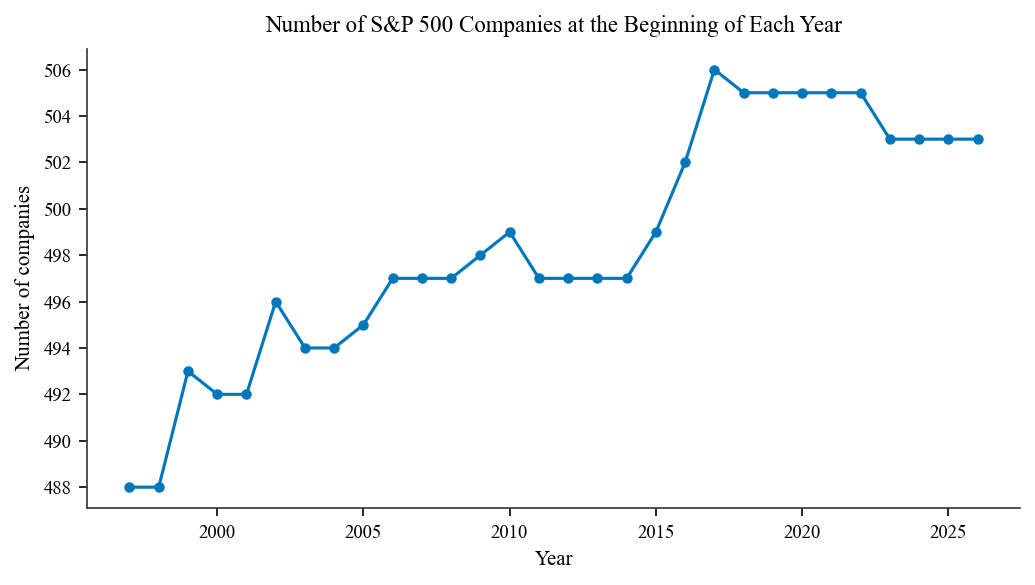

,Year,NumCompanies
0,1997,488.0
1,1998,488.0
2,1999,493.0
3,2000,492.0
4,2001,492.0
5,2002,496.0
6,2003,494.0
7,2004,494.0
8,2005,495.0
9,2006,497.0


In [7]:
plots.SP500.companies_per_year_start(sp500_components)

Na przestrzeni ostatnich 30 lat można zauważyć spadek rotacji w indeksie w porównaniu z okresem bańki internetowej w 2000 roku oraz latami poprzedzającymi kryzys 2008 roku, a w ciągu ostatnich 15 lat rotacja ustabilizowała się na poziomie około 20 spółek rocznie. Zmiany w składzie indeksu oraz częstotliwość selekcji będą miały wpływ na skład tworzonych portfeli.

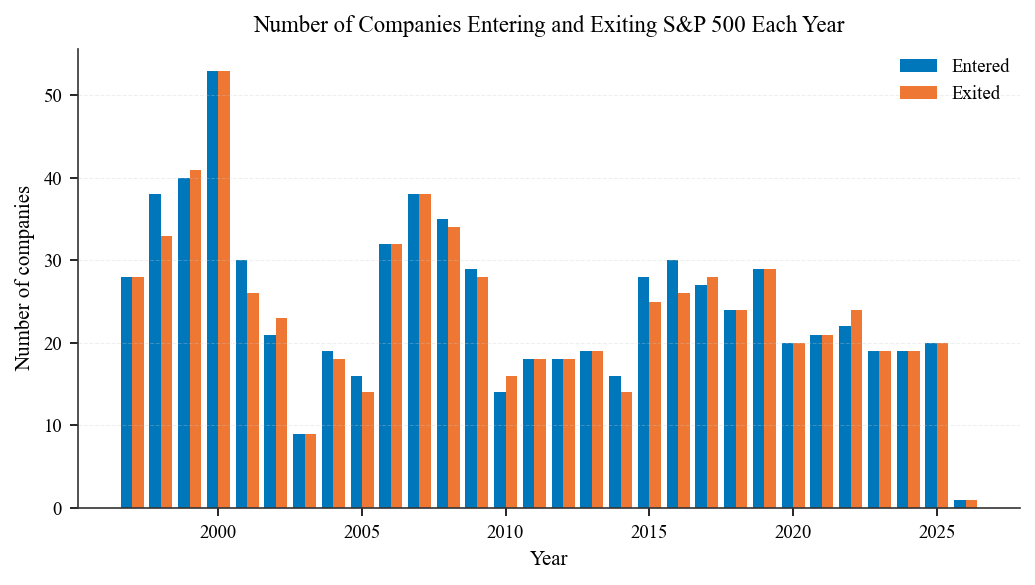

,Year,Entered,Exited
0,1997,28,28
1,1998,38,33
2,1999,40,41
3,2000,53,53
4,2001,30,26
5,2002,21,23
6,2003,9,9
7,2004,19,18
8,2005,16,14
9,2006,32,32


In [8]:
plots.SP500.yearly_changes(sp500_components)

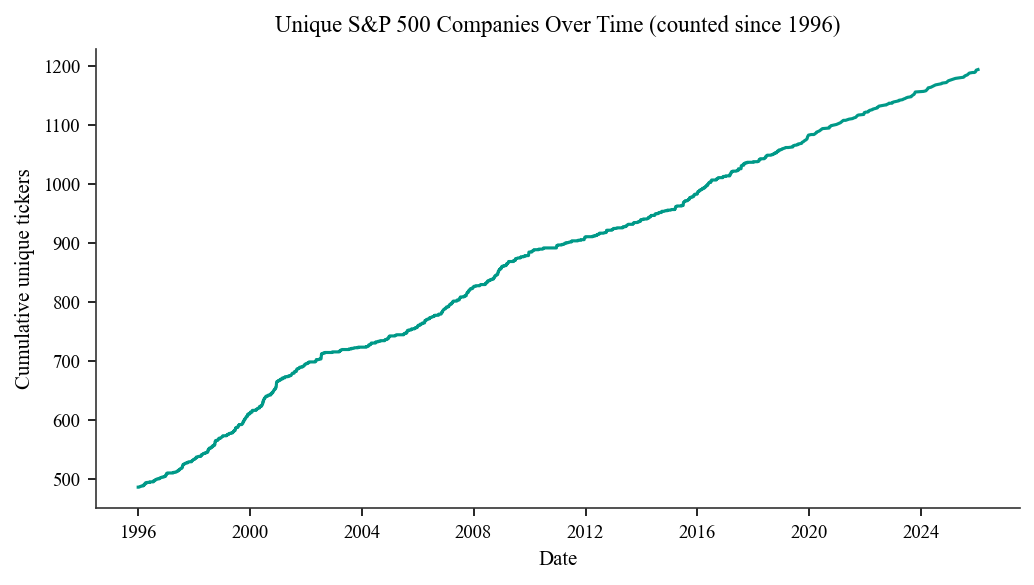

1194 unique companies were listed in the S&P 500 over the period 1996-01-02 → 2026-01-14 (30 years, 0 months)


,date,tickers,unique_cum
0,1996-01-02,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...",487
1,1996-01-03,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...",487
2,1996-01-04,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...",487
3,1996-01-10,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...",487
4,1996-01-11,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...",487
...,...,...,...
2700,2025-11-11,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...",1189
2701,2025-11-28,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...",1189
2702,2025-12-11,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...",1190
2703,2025-12-22,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...",1193


In [9]:
plots.SP500.count_unique_companies(sp500_components)

## Dane cenowe

Do selekcji spółek do portfela z wykorzystaniem analizy technicznej w dłuższym terminie wystarczają wartości uzyskane pod koniec sesji każdego dnia (**End-of-Day, EOD**). Ponieważ dane muszą obejmować również spółki, które już nie istnieją, aby uniknąć błędów badawczych, darmowe źródła często okazują się niewystarczające. W praktyce można przyjąć dwa podejścia:

- pobranie danych cenowych z darmowych źródeł i uzupełnienie brakujących danych profesjonalnym dostawcą

- pobranie wszystkich danych bezpośrednio od profesjonalnego dostawcy.

W tym projekcie wybrane zostało pierwsze podejście, aby zwizualizować potencjalny wpływ brakujących lub niekompletnych danych na wyniki analizy.

### Dane cenowe z Yahoo Finance

Najpopularniejszą opcją pozyskania danych cenowych jest korzystanie z [**Yahoo Finance**](https://finance.yahoo.com/?guccounter=1), np. poprzez bibliotekę [**yfinance**](https://github.com/ranaroussi/yfinance) w Pythonie, która umożliwia pobranie danych historycznych spółek wraz z cenami skorygowanymi o splity i dywidendy.

#### Uzyskanie danych z pojedynczej spółki

Poniżej przykładowe użycie tej biblioteki w celu uzyskania historii cen akcji spółki Apple (AAPL). Dane cenowe zamknięcia (**Adj Close**) są już skorygowane o dywidendy.

In [10]:
apple = dataset.YahooFinance.get_ticker_data_incremential("AAPL", save_csv=True)

plots.summarize_df(apple)

Loading existing data for AAPL from AAPL.csv
Fetching new data for AAPL since 2026-04-02
Updated AAPL with new data
Saved data for AAPL to AAPL.csv
DataFrame summary:
<class 'pandas.DataFrame'>
Index: 11418 entries, 1980-12-12 05:00:00+00:00 to 2026-04-02 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          11418 non-null  float64
 1   High          11418 non-null  float64
 2   Low           11418 non-null  float64
 3   Close         11418 non-null  float64
 4   Adj Close     11418 non-null  float64
 5   Volume        11418 non-null  int64  
 6   Dividends     11418 non-null  float64
 7   Stock Splits  11418 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 802.8+ KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,11418.000000,11418.000000,11418.000000,11418.000000,11418.000000,1.141800e+04,11418.000000,11418.000000
mean,30.150473,30.476174,29.842099,30.171592,29.219515,3.082849e+08,0.000881,0.001489
std,60.610791,61.258826,60.009242,60.658934,60.121352,3.330530e+08,0.013150,0.082110
min,0.049665,0.049665,0.049107,0.049107,0.037609,0.000000e+00,0.000000,0.000000
25%,0.305062,0.311384,0.299107,0.305246,0.247406,1.053441e+08,0.000000,0.000000
50%,0.607143,0.620536,0.596540,0.606864,0.496092,1.971956e+08,0.000000,0.000000
75%,24.554554,24.785625,24.278750,24.496875,21.923542,3.883216e+08,0.000000,0.000000
max,286.200012,288.619995,283.299988,286.190002,285.922455,7.421641e+09,0.260000,7.000000


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1980-12-12 05:00:00+00:00,0.128348,0.128906,0.128348,0.128348,0.098298,469033600,0.0,0.0
1980-12-15 05:00:00+00:00,0.122210,0.122210,0.121652,0.121652,0.093169,175884800,0.0,0.0
2026-04-01 04:00:00+00:00,254.080002,256.179993,253.330002,255.630005,255.630005,40059400,0.0,0.0
2026-04-02 00:00:00-04:00,254.199997,256.130005,250.649994,255.919998,255.919998,31289400,0.0,0.0


Poniższy fragment danych — dzień przed, w dniu oraz dzień po splicie akcji — pokazuje, że ceny w danych historycznych uwzględniają już split.

In [11]:
plots.YahooFinance.show_last_split(apple)

,Open,Adj Close,Dividends,Stock Splits
Date,,,,
2020-08-28 04:00:00+00:00,126.012497,121.171524,0.0,0.0
2020-08-31 04:00:00+00:00,127.580002,125.280701,0.0,4.0
2020-09-01 04:00:00+00:00,132.759995,130.270996,0.0,0.0


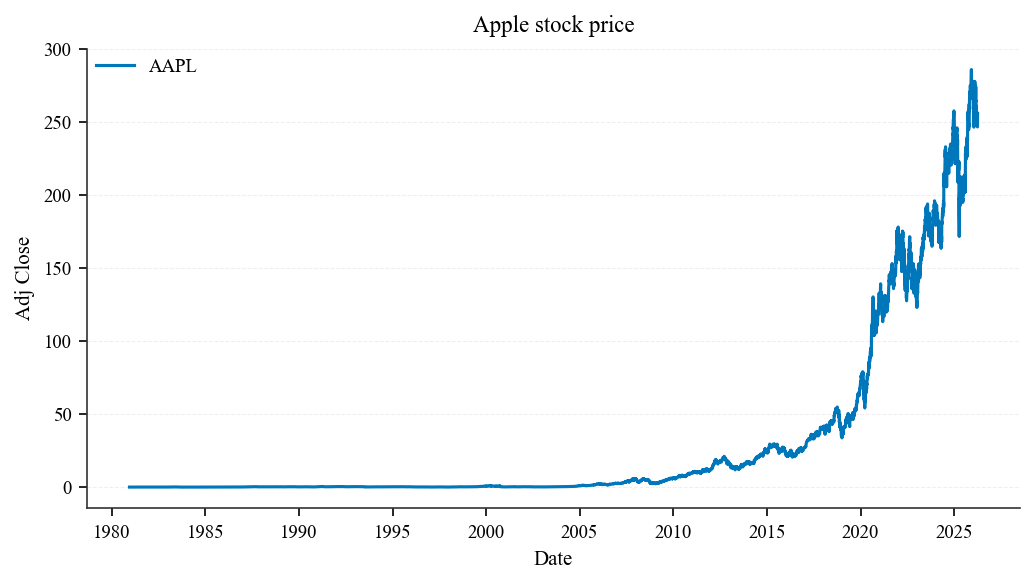

,AAPL
Date,
1980-12-12,0.098298
1980-12-15,0.093169
1980-12-16,0.086331
1980-12-17,0.088468
1980-12-18,0.091032
...,...
2026-03-27,248.800003
2026-03-30,246.630005
2026-03-31,253.789993


In [12]:
plots.YahooFinance.show_chart(apple, "AAPL", title="Apple stock price", hide_col=True)

#### Uzyskanie danych o indeksie

Na platformie Yahoo Finance dostępne są różne tickery reprezentujące indeks S&P 500, które różnią się sposobem uwzględniania dywidend:

- **SP500 (^GSPC, S&P 500)** – indeks cenowy (*price return*), uwzględniający wyłącznie zmiany cen akcji spółek wchodzących w skład indeksu
- **SP500TR (^SP500TR, S&P 500 Total Return)** – indeks dochodowy (*total return*), uwzględniający zarówno zmiany cen, jak i reinwestowane dywidendy
- **ETF (CSPX.L, iShares Core S&P 500 UCITS ETF Acc)** – fundusz ETF replikujący indeks S&P 500 w sposób fizyczny, akumulujący dywidendy (reinwestowane wewnątrz funduszu), stanowiący przybliżenie rzeczywistej stopy zwrotu inwestora

Zestawienie tych trzech instrumentów pozwala porównać:
- wpływ dywidend na długoterminową stopę zwrotu,
- różnice między indeksem teoretycznym a rzeczywistym instrumentem inwestycyjnym,
- dokładność odwzorowania indeksu przez ETF (tzw. *tracking error*).

In [13]:
SP500 = dataset.YahooFinance.get_ticker_data_incremential("^GSPC", save_csv=True)
SP500TR = dataset.YahooFinance.get_ticker_data_incremential("^SP500TR", save_csv=True)
ETF = dataset.YahooFinance.get_ticker_data_incremential("CSPX.L", save_csv=True)

plots.summarize_df(SP500)
plots.summarize_df(SP500TR)
plots.summarize_df(ETF)

Loading existing data for ^GSPC from ^GSPC.csv
Fetching new data for ^GSPC since 2026-04-02
Updated ^GSPC with new data
Saved data for ^GSPC to ^GSPC.csv
Loading existing data for ^SP500TR from ^SP500TR.csv
Fetching new data for ^SP500TR since 2026-04-02
Updated ^SP500TR with new data
Saved data for ^SP500TR to ^SP500TR.csv
Loading existing data for CSPX.L from CSPX.L.csv
Fetching new data for CSPX.L since 2026-04-01
Updated CSPX.L with new data
Saved data for CSPX.L to CSPX.L.csv
DataFrame summary:
<class 'pandas.DataFrame'>
Index: 24680 entries, 1927-12-30 05:00:00+00:00 to 2026-04-02 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          24680 non-null  float64
 1   High          24680 non-null  float64
 2   Low           24680 non-null  float64
 3   Close         24680 non-null  float64
 4   Adj Close     24680 non-null  float64
 5   Volume        24680 non-null  int64  
 6   Dividends 

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,24680.000000,24680.000000,24680.000000,24680.000000,24680.000000,2.468000e+04,24680.0,24680.0
mean,730.261532,734.457825,725.787810,730.403593,730.403593,9.739908e+08,0.0,0.0
std,1252.783422,1259.413696,1245.596118,1252.962260,1252.962260,1.691694e+09,0.0,0.0
min,4.400000,4.400000,4.400000,4.400000,4.400000,0.000000e+00,0.0,0.0
25%,24.957500,24.957500,24.957500,24.957500,24.957500,1.600000e+06,0.0,0.0
50%,103.615002,104.419998,102.775002,103.610001,103.610001,2.231000e+07,0.0,0.0
75%,1093.572540,1099.520020,1084.667511,1093.284973,1093.284973,1.186598e+09,0.0,0.0
max,7002.000000,7002.279785,6963.459961,6978.600098,6978.600098,1.145623e+10,0.0,0.0


DataFrame summary:
<class 'pandas.DataFrame'>
Index: 9635 entries, 1988-01-04 05:00:00+00:00 to 2026-04-02 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          9635 non-null   float64
 1   High          9635 non-null   float64
 2   Low           9635 non-null   float64
 3   Close         9635 non-null   float64
 4   Adj Close     9635 non-null   float64
 5   Volume        9635 non-null   int64  
 6   Dividends     9635 non-null   float64
 7   Stock Splits  9635 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 677.5+ KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,9635.000000,9635.000000,9635.000000,9635.000000,9635.000000,9635.0,9635.0,9635.0
mean,3289.402619,3303.384659,3274.387288,3289.934884,3289.934884,0.0,0.0,0.0
std,3424.466035,3443.870062,3403.377895,3424.912048,3424.912048,0.0,0.0,0.0
min,242.869995,242.869995,242.869995,242.869995,242.869995,0.0,0.0,0.0
25%,1168.394958,1168.394958,1168.394958,1168.394958,1168.394958,0.0,0.0,0.0
50%,1916.599976,1919.839966,1914.089966,1917.250000,1917.250000,0.0,0.0,0.0
75%,4097.349854,4107.844971,4076.715088,4095.430054,4095.430054,0.0,0.0,0.0
max,15580.040039,15580.589844,15494.280273,15527.820312,15527.820312,0.0,0.0,0.0


DataFrame summary:
<class 'pandas.DataFrame'>
Index: 3926 entries, 2010-09-14 23:00:00+00:00 to 2026-04-02 00:00:00+01:00
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           3926 non-null   float64
 1   High           3926 non-null   float64
 2   Low            3926 non-null   float64
 3   Close          3926 non-null   float64
 4   Adj Close      3926 non-null   float64
 5   Volume         3926 non-null   int64  
 6   Dividends      3926 non-null   float64
 7   Stock Splits   3926 non-null   float64
 8   Capital Gains  3926 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 306.7+ KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
count,3926.000000,3926.000000,3926.000000,3926.000000,3926.000000,3.926000e+03,3926.0,3926.0,3926.0
mean,308.446997,314.559537,306.684144,308.475018,308.475018,9.689363e+04,0.0,0.0,0.0
std,172.375776,183.205546,171.314821,172.406900,172.406900,1.184927e+05,0.0,0.0,0.0
min,94.239998,94.500000,1.000000,94.584999,94.584999,0.000000e+00,0.0,0.0,0.0
25%,176.539993,177.360004,175.292496,176.327507,176.327507,1.979700e+04,0.0,0.0,0.0
50%,262.639999,263.705002,261.115005,262.760010,262.760010,7.371250e+04,0.0,0.0,0.0
75%,428.642494,430.392494,426.009995,428.307495,428.307495,1.283888e+05,0.0,0.0,0.0
max,751.090027,888.760010,746.714172,748.880005,748.880005,1.665039e+06,0.0,0.0,0.0


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,,
2010-09-14 23:00:00+00:00,95.820000,95.820000,95.820000,95.540001,95.540001,1,0.0,0.0,0.0
2010-09-15 23:00:00+00:00,95.540001,95.540001,95.540001,95.540001,95.540001,0,0.0,0.0,0.0
2026-03-30 23:00:00+00:00,686.549988,700.117981,685.299988,691.140015,691.140015,267311,0.0,0.0,0.0
2026-04-02 00:00:00+01:00,697.520020,709.969971,694.309998,705.909973,705.909973,144108,0.0,0.0,0.0


Wyniki z kolumny Close i Adj Close są jednakowe.

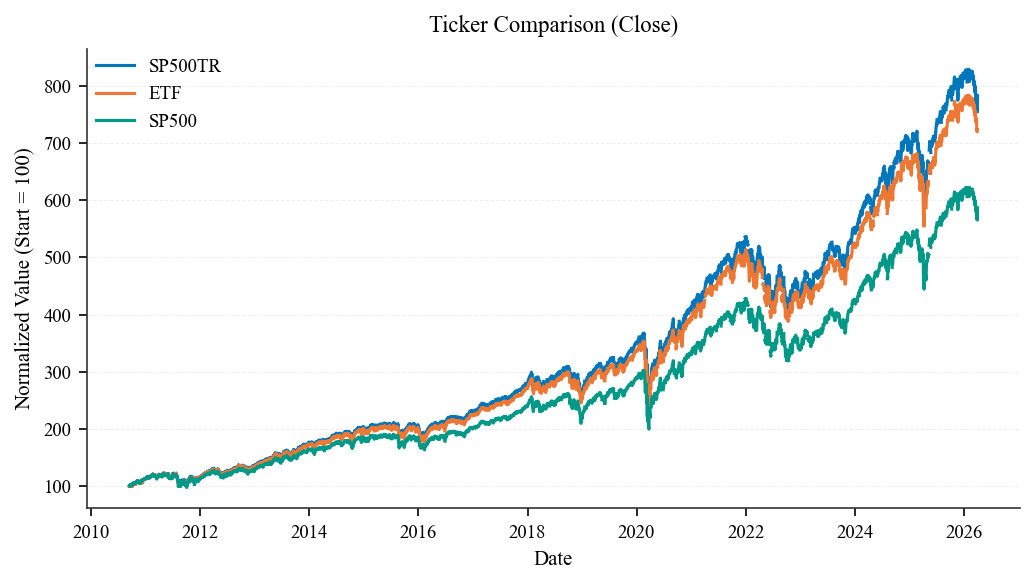

,SP500TR,ETF,SP500
Date,,,
2010-09-14,100.000000,100.000000,100.000000
2010-09-15,100.355912,100.000000,100.354114
2010-09-16,100.336169,100.000000,100.317551
2010-09-17,100.419414,NaN,100.400499
2010-09-19,NaN,100.000000,NaN
...,...,...,...
2026-03-27,757.882077,720.996462,568.089398
2026-03-29,NaN,719.771799,NaN
2026-03-30,754.897628,723.403818,565.847860


In [14]:
plots.YahooFinance.compare_tickers({
    "SP500": SP500,
    "SP500TR": SP500TR,
    "ETF": ETF
}, col="Close")

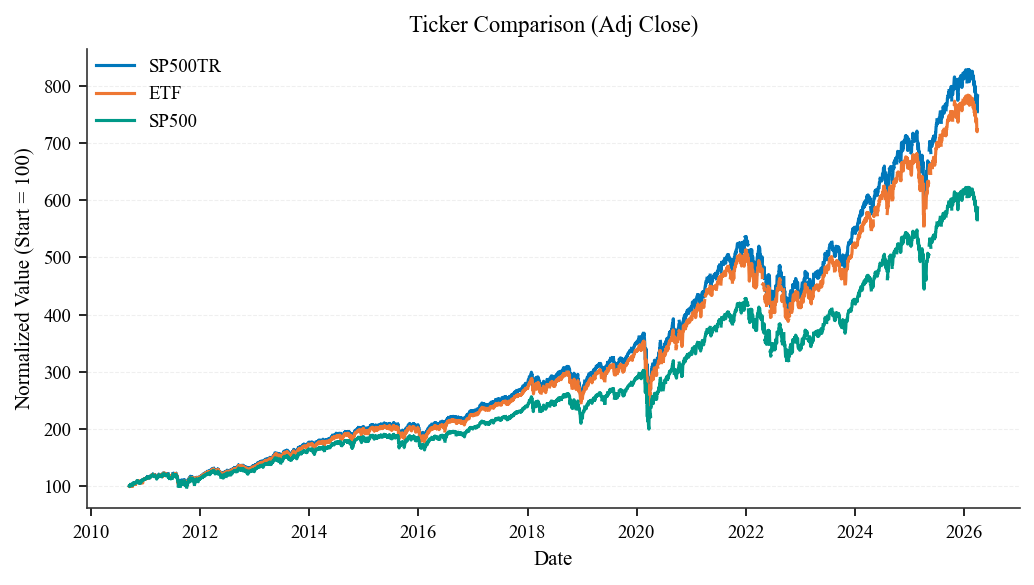

,SP500TR,ETF,SP500
Date,,,
2010-09-14,100.000000,100.000000,100.000000
2010-09-15,100.355912,100.000000,100.354114
2010-09-16,100.336169,100.000000,100.317551
2010-09-17,100.419414,NaN,100.400499
2010-09-19,NaN,100.000000,NaN
...,...,...,...
2026-03-27,757.882077,720.996462,568.089398
2026-03-29,NaN,719.771799,NaN
2026-03-30,754.897628,723.403818,565.847860


In [15]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "SP500": SP500,
    "ETF": ETF
}, col="Adj Close")

Widzimy nie tylko różnicę między indeksem uwzględniającym dywidendy a tym nieuwzględniającym, ale także między indeksem total return a odpowiadającym mu ETF-em, który zwykle osiąga nieco niższe wyniki z powodu **błędu odwzorowania** (tracking error). Przy porównywaniu stóp zwrotu portfela z wynikami indeksu (ETF-a) oraz uwzględniając fakt, że ETF-y zyskały szeroką popularność dopiero po kryzysie finansowym, warto wziąć pod uwagę ETF – fizyczny, akumulujący ETF z najdłuższą historią na Yahoo Finance. Utworzenie **hybrydowego indeksu**, uwzględniającego efekty tracking error, pozwala lepiej odzwierciedlić rzeczywiste wyniki inwestora.

#### Hybrydowy indeks S&P 500

Do konstrukcji hybrydowego indeksu rozważono podejścia oparte na **splicingu**, tj. łączeniu fragmentów szeregów czasowych w jedną spójną serię. Przyjęto, że w okresie dostępności ETF-u indeks hybrydowy odpowiada jego rzeczywistym notowaniom, natomiast wcześniejsze obserwacje są rekonstruowane na podstawie indeksu SP500TR.

Rozważono następujące podejścia:

1. **Proste skalowanie** — dane SP500TR są skalowane tak, aby ich wartość w punkcie łączenia była zgodna z wartością ETF-u.

2. **Bezwzględna różnica odwzorowania (tracking difference)** — w okresie wspólnym estymowana jest średnia różnica stóp zwrotu:

   $$\overline{\text{TD}} = \frac{1}{T}\sum_{t=1}^{T}(R_{\text{TR}} - R_{\text{ETF}}),$$

   która następnie koryguje historyczne stopy zwrotu:

   $$r_{\text{HYB}} = R_{\text{TR}} - \overline{\text{TD}}.$$

   Podejście to pomija jednak kumulatywny charakter błędu odwzorowania oraz jego proporcjonalność do poziomu cen.

3. **Względna różnica odwzorowania** — w okresie wspólnym estymowana jest relatywna różnica wyników ETF względem indeksu:

   $$
   TD_{annual} = \left(\frac{R_{\text{TR}}}{R_{\text{ETF}}}\right)^{\frac{252}{N}} - 1,
   $$

   gdzie $R_{\text{TR}}$ i $R_{\text{ETF}}$ oznaczają całkowite stopy zwrotu, a $N$ liczbę dni sesyjnych.

   Otrzymany parametr interpretowany jest jako średni roczny koszt odwzorowania i przekształcany do dziennego czynnika, który jest następnie kumulowany wstecznie:

   $$
   P^{adj}_t = \frac{P_t}{d^k}, \quad d = (1 + TD_{annual})^{1/252},
   $$

   gdzie $k$ oznacza liczbę dni od momentu rozpoczęcia notowań ETF.

   Tak skorygowana seria jest następnie skalowana w punkcie łączenia w celu zapewnienia ciągłości z rzeczywistymi notowaniami ETF.

Do utworzenia benchmarku przyjęto **trzecie podejście**, ponieważ pozwala ono uchwycić kumulatywny charakter błędu odwzorowania, przy jednoczesnym zachowaniu prostoty i stabilności estymacji oraz pełnej zgodności z obserwowanymi danymi ETF po dacie jego debiutu.

Loading existing benchmark from D:\Michal\Documents\Education\University\Semestr 4\Projekt indywidualny\Repo\data\processed\benchmark_2026-04-03.csv
DataFrame summary:
<class 'pandas.DataFrame'>
Index: 24680 entries, 1927-12-30 05:00:00+00:00 to 2026-04-02 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          24680 non-null  float64
 1   High          24680 non-null  float64
 2   Low           24680 non-null  float64
 3   Close         24680 non-null  float64
 4   Adj Close     24680 non-null  float64
 5   Volume        24680 non-null  int64  
 6   Dividends     24680 non-null  float64
 7   Stock Splits  24680 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 1.7+ MB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,24680.000000,24680.000000,24680.000000,24680.000000,24680.000000,2.468000e+04,24680.0,24680.0
mean,730.261532,734.457825,725.787810,730.403593,730.403593,9.739908e+08,0.0,0.0
std,1252.783422,1259.413696,1245.596118,1252.962260,1252.962260,1.691694e+09,0.0,0.0
min,4.400000,4.400000,4.400000,4.400000,4.400000,0.000000e+00,0.0,0.0
25%,24.957500,24.957500,24.957500,24.957500,24.957500,1.600000e+06,0.0,0.0
50%,103.615002,104.419998,102.775002,103.610001,103.610001,2.231000e+07,0.0,0.0
75%,1093.572540,1099.520020,1084.667511,1093.284973,1093.284973,1.186598e+09,0.0,0.0
max,7002.000000,7002.279785,6963.459961,6978.600098,6978.600098,1.145623e+10,0.0,0.0


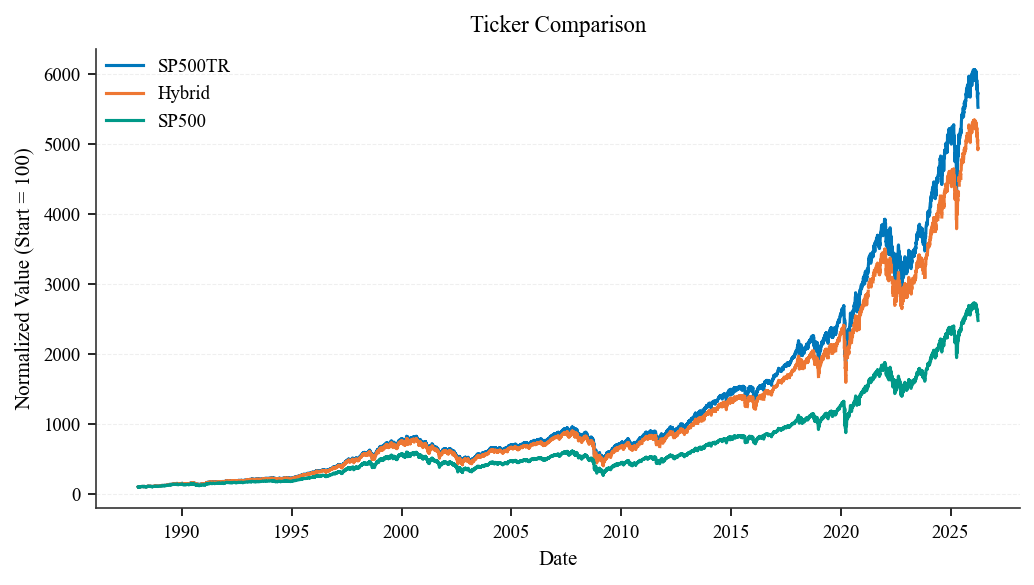

,SP500TR,Hybrid,SP500
Date,,,
1988-01-04,100.000000,100.000000,100.000000
1988-01-05,101.074135,101.072876,101.051029
1988-01-06,101.175693,101.173173,101.152619
1988-01-07,102.027186,102.023375,102.004378
1988-01-08,95.129292,95.124554,95.100411
...,...,...,...
2026-03-24,5710.639993,5044.965814,2561.682447
2026-03-25,5741.809358,5065.385758,2575.564523
2026-03-26,5641.887732,4999.341896,2530.733803


In [16]:
import importlib
importlib.reload(features)

benchmark = features.construct_hybrid(
    long_df=SP500TR,
    short_df=ETF,
    save_csv=True,
    cleanup_old=True
)

plots.summarize_df(SP500)

plots.YahooFinance.compare_tickers({
    "Hybrid": benchmark,
    "SP500TR": SP500TR,
    # "ETF": ETF, # here shows only after 2010-09-14
    "SP500": SP500
}, hide_col=True)

Poniżej przedstawiono wizualizację dwóch okresów hybrydowego indeksu:  
- **przed debiutem ETF** – historyczne notowania odtworzone na podstawie SP500TR z uwzględnieniem tracking difference.  
- **po debiucie ETF** – hybrydowy indeks pokrywa się z ETF-em.

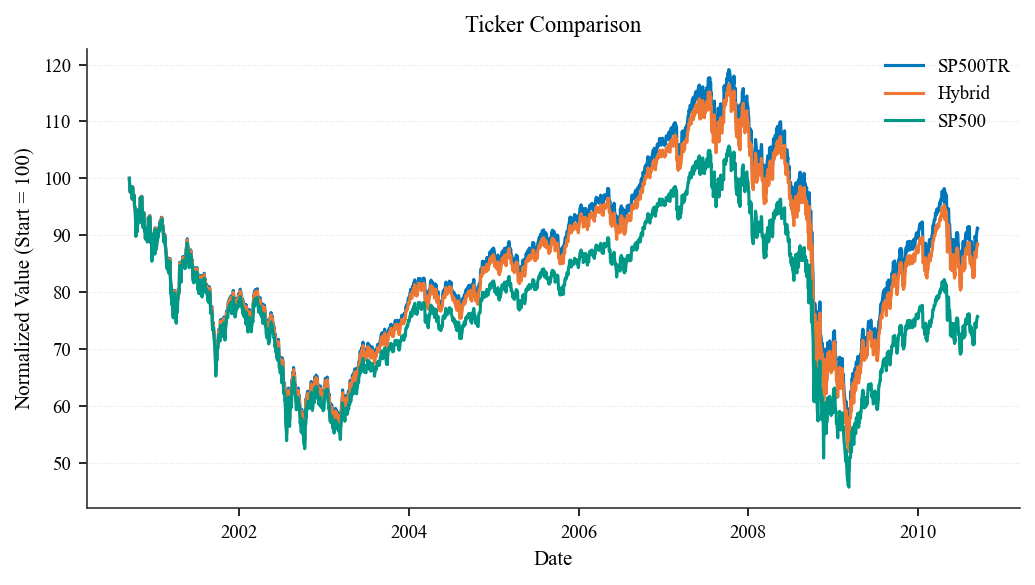

,SP500TR,Hybrid,SP500
Date,,,
2000-09-14,100.000000,100.000000,100.000000
2000-09-15,98.983063,98.981831,98.983035
2000-09-18,97.546507,97.544077,97.544688
2000-09-19,98.586322,98.582639,98.583942
2000-09-20,98.010428,98.005546,98.005900
...,...,...,...
2010-09-08,89.387648,86.637924,74.204353
2010-09-09,89.819931,87.055826,74.562930
2010-09-10,90.258543,87.479850,74.925554


In [22]:
plots.YahooFinance.compare_tickers({
    "Hybrid": benchmark,
    "SP500TR": SP500TR,
    "SP500": SP500
}, hide_col=True, start_date="2000-09-14", end_date="2010-09-14")

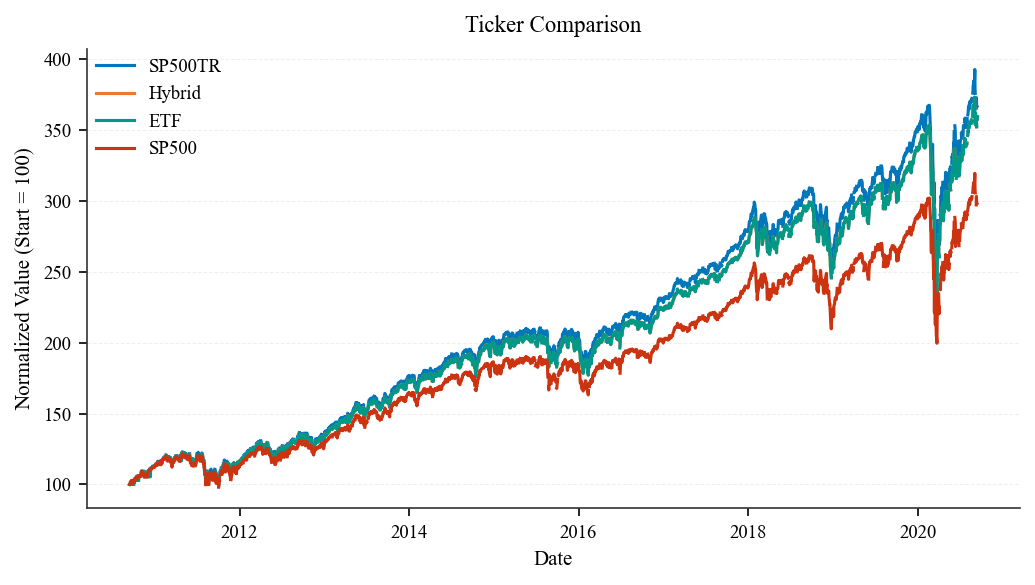

,SP500TR,Hybrid,ETF,SP500
Date,,,,
2010-09-14,100.000000,100.000000,100.000000,100.000000
2010-09-15,100.355912,100.000000,100.000000,100.354114
2010-09-16,100.336169,100.000000,100.000000,100.317551
2010-09-17,100.419414,NaN,NaN,100.400499
2010-09-19,NaN,NaN,100.000000,NaN
...,...,...,...,...
2020-09-09,372.812113,357.891971,357.891971,303.180808
2020-09-10,366.273948,352.260817,352.260817,297.849435
2020-09-11,366.486866,NaN,NaN,298.008210


In [23]:
plots.YahooFinance.compare_tickers({
    "Hybrid": benchmark,
    "SP500TR": SP500TR,
    "ETF": ETF,
    "SP500": SP500
}, hide_col=True, start_date="2010-09-14", end_date="2020-09-14")

#### Uzyskanie danych składowych indeksu

In [24]:
sp500_components.head()

# TODO: Download stock price data from yfinance (Issue #1 - https://github.com/MichaelL200/data-driven-stock-portfolio-selection/issues/1)

,date,tickers
0,1996-01-02,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
1,1996-01-03,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
2,1996-01-04,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
3,1996-01-10,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
4,1996-01-11,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."


In [25]:
microsoft = dataset.YahooFinance.get_ticker_data_incremential("MSFT", save_csv=True)
plots.summarize_df(microsoft)

Loading existing data for MSFT from MSFT.csv
Fetching new data for MSFT since 2026-04-02
Updated MSFT with new data
Saved data for MSFT to MSFT.csv
DataFrame summary:
<class 'pandas.DataFrame'>
Index: 10092 entries, 1986-03-13 05:00:00+00:00 to 2026-04-02 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          10092 non-null  float64
 1   High          10092 non-null  float64
 2   Low           10092 non-null  float64
 3   Close         10092 non-null  float64
 4   Adj Close     10092 non-null  float64
 5   Volume        10092 non-null  int64  
 6   Dividends     10092 non-null  float64
 7   Stock Splits  10092 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 709.6+ KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,10092.000000,10092.000000,10092.000000,10092.000000,10092.000000,1.009200e+04,10092.000000,10092.000000
mean,74.569000,75.301869,73.803020,74.576940,68.412335,5.540738e+07,0.003441,0.001685
std,117.883681,118.906433,116.762947,117.873677,117.515400,3.798144e+07,0.050636,0.056726
min,0.088542,0.092014,0.088542,0.090278,0.055021,2.304000e+06,0.000000,0.000000
25%,6.257813,6.363282,6.190430,6.257813,3.813917,3.025102e+07,0.000000,0.000000
50%,27.820000,28.150000,27.545000,27.850000,19.490497,4.861890e+07,0.000000,0.000000
75%,53.960001,54.409376,53.412501,53.997499,46.564332,6.934130e+07,0.000000,0.000000
max,555.229980,555.450012,540.770020,542.070007,539.825256,1.031789e+09,3.080000,2.000000


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1986-03-13 05:00:00+00:00,0.088542,0.101563,0.088542,0.097222,0.059253,1031788800,0.0,0.0
1986-03-14 05:00:00+00:00,0.097222,0.102431,0.097222,0.100694,0.061369,308160000,0.0,0.0
2026-04-01 04:00:00+00:00,373.489990,373.989990,368.200012,369.369995,369.369995,29417200,0.0,0.0
2026-04-02 00:00:00-04:00,367.209991,373.640015,364.149994,373.459991,373.459991,24099100,0.0,0.0


#### Ile danych brakuje?

In [26]:
# TODO: Check how many stocks are not covered by yfinanc (Issue #1 - https://github.com/MichaelL200/data-driven-stock-portfolio-selection/issues/1)

### Dane cenowe z EODHD

...

In [27]:
# TODO: Download missing stock price data from EODHD (Issue #4 - https://github.com/MichaelL200/data-driven-stock-portfolio-selection/issues/4)